# EGARCH(1,1,1) with Student-$t$ Innovations: Asymmetric Volatility and CVaR Estimation for SPY

**Objective.** This notebook fits an Exponential GARCH model of order $(p,o,q) = (1,1,1)$ to the log-return series of the SPY ETF, diagnoses model adequacy via standardized residual analysis, and derives a one-step-ahead 95% Conditional Value-at-Risk (CVaR) forecast for the terminal observation in the sample.

The treatment is self-contained: each code cell is preceded by a Markdown cell deriving the relevant theory from first principles.

---
## 1. Theoretical Motivation: Why Standard GARCH Is Insufficient

The canonical GARCH$(p,q)$ model of Bollerslev (1986) specifies the conditional variance as

$$
\sigma_t^2 = \omega + \sum_{i=1}^{q} \alpha_i \epsilon_{t-i}^2 + \sum_{j=1}^{p} \beta_j \sigma_{t-j}^2
$$

with the structural constraint $\omega > 0$, $\alpha_i \geq 0$, $\beta_j \geq 0$ to guarantee $\sigma_t^2 > 0$ almost surely.

Two empirical regularities of equity returns violate the symmetry implicit in this specification:

1. **The Leverage Effect** (Black, 1976; Christie, 1982): Negative return shocks increase future volatility by *more* than positive shocks of equal magnitude. This is captured by $\operatorname{Cov}(r_t, \sigma_{t+1}^2) < 0$, which the standard GARCH model — where only $\epsilon_t^2$ appears — cannot reproduce.

2. **Positivity Constraints on Coefficients**: The non-negativity restrictions in GARCH are sufficient but not necessary for $\sigma_t^2 > 0$, and they unnecessarily constrain the parameter space during estimation.

Nelson (1991) resolved both issues with the **Exponential GARCH (EGARCH)** model, specified in log-variance space.

---
## 2. The EGARCH$(p, o, q)$ Model: Mathematical Framework

Let $r_t$ denote the log-return at time $t$ and define the innovation process $\epsilon_t = r_t - \mu$ where $\mu$ is the unconditional mean. The standardized shock is $z_t = \epsilon_t / \sigma_t$. The EGARCH$(1,1,1)$ model is:

$$
\ln \sigma_t^2 = \omega + \alpha_1 \left( |z_{t-1}| - \mathbb{E}[|z_{t-1}|] \right) + \gamma_1 z_{t-1} + \beta_1 \ln \sigma_{t-1}^2
$$

**Parameter interpretation:**

| Parameter | Role |
|-----------|------|
| $\omega$ | Unconditional log-variance level |
| $\alpha_1$ | ARCH effect: magnitude of standardized shock |
| $\gamma_1$ | **Asymmetry (leverage) parameter** |
| $\beta_1$ | GARCH persistence (typically $|\beta_1| < 1$) |

**Why the log specification eliminates positivity constraints:** Since the equation is written for $\ln \sigma_t^2$, the conditional variance is $\sigma_t^2 = \exp(\ln \sigma_t^2) > 0$ by construction for any real-valued parameter vector. No sign restrictions are required.

**Why $\gamma_1$ captures asymmetry:** For a negative shock $z_{t-1} = -|z|$:

$$
\alpha_1 |z_{t-1}| + \gamma_1 z_{t-1} = (\alpha_1 - \gamma_1)|z|
$$

For a positive shock $z_{t-1} = +|z|$:

$$
\alpha_1 |z_{t-1}| + \gamma_1 z_{t-1} = (\alpha_1 + \gamma_1)|z|
$$

The leverage effect corresponds to $\gamma_1 < 0$, so that negative shocks amplify volatility more than positive shocks. The empirical expectation for equity indices is $\hat{\gamma}_1 \in (-0.2, -0.05)$.

**Stationarity condition:** The process is strictly stationary if and only if $|\beta_1| < 1$. The unconditional log-variance is $\mathbb{E}[\ln \sigma_t^2] = \omega / (1 - \beta_1)$.

---
## 3. The Student-$t$ Innovation Distribution

Under the assumption of Gaussian innovations, the log-likelihood is:

$$
\ell_N(\theta) = -\frac{T}{2}\ln(2\pi) - \frac{1}{2}\sum_{t=1}^{T} \left( \ln \sigma_t^2 + z_t^2 \right)
$$

Equity return distributions exhibit **excess kurtosis** (fat tails), rendering Gaussian MLE inconsistent and understating tail risk. We instead assume $z_t \sim t_\nu$ (standardized Student-$t$ with $\nu$ degrees of freedom), whose PDF is:

$$
f(z_t; \nu) = \frac{\Gamma\left(\frac{\nu+1}{2}\right)}{\sqrt{\pi(\nu-2)}\,\Gamma\left(\frac{\nu}{2}\right)} \left(1 + \frac{z_t^2}{\nu - 2}\right)^{-\frac{\nu+1}{2}}
$$

normalized so that $\operatorname{Var}(z_t) = 1$ for $\nu > 2$. The log-likelihood becomes:

$$
\ell_t(\theta) = \ln\Gamma\!\left(\tfrac{\nu+1}{2}\right) - \ln\Gamma\!\left(\tfrac{\nu}{2}\right) - \tfrac{1}{2}\ln[\pi(\nu-2)] - \tfrac{1}{2}\ln\sigma_t^2 - \tfrac{\nu+1}{2}\ln\!\left(1 + \frac{z_t^2}{\nu-2}\right)
$$

The full sample log-likelihood $\mathcal{L}(\theta) = \sum_{t=1}^{T} \ell_t(\theta)$ is maximized over $\theta = (\mu, \omega, \alpha_1, \gamma_1, \beta_1, \nu)^\top$.

**Failure mode:** For $\nu \leq 2$ the variance is infinite and MLE is ill-posed. The optimizer should constrain $\nu > 2$ (the `arch` library enforces $\nu > 2$ by default).

In [4]:
# ── 0. Imports ────────────────────────────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yfinance as yf
from arch import arch_model
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

---
## 4. Data Acquisition and Log-Return Construction

Let $P_t$ denote the adjusted closing price of SPY at time $t$. The continuously compounded (log) return is:

$$
r_t = 100 \cdot \ln\!\left(\frac{P_t}{P_{t-1}}\right)
$$

The multiplicative factor of 100 re-scales returns from decimal (e.g., $0.012$) to percentage units (e.g., $1.2$). This is **not** a cosmetic convention: the MLE landscape for GARCH-type models is notoriously flat when the data are on the order of $10^{-2}$, leading to poor numerical convergence. Scaling to percentage units places the unconditional variance $\hat{\sigma}^2$ in the range $[0.5, 2.5]$, which is within the region where standard BFGS and L-BFGS-B optimizers perform reliably.

**Failure mode:** Forgetting to invert the scaling when computing VaR/CVaR in the application step. All risk metrics computed below will be in percentage-point units and must be divided by 100 before applying to a dollar-denominated portfolio.

In [5]:
# ── 1. Data Download ──────────────────────────────────────────────────────────
TICKER   = 'SPY'
END_DATE = pd.Timestamp.today().normalize()
START_DATE = END_DATE - pd.DateOffset(years=10)

raw = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)

close = raw['Close']
if isinstance(close, pd.DataFrame):
    close = close.iloc[:, 0]

prices = close.dropna()
log_returns = 100 * np.log(prices / prices.shift(1)).dropna()
if isinstance(log_returns, pd.DataFrame):
    log_returns = log_returns.iloc[:, 0]
log_returns.name = 'log_ret'

print(f"Sample period : {log_returns.index[0].date()} → {log_returns.index[-1].date()}")
print(f"Observations  : {len(log_returns):,}")
print(f"\nDescriptive statistics (% units):")
desc = log_returns.describe()
desc.loc['skewness'] = log_returns.skew()
desc.loc['excess kurtosis'] = log_returns.kurt()
print(desc.to_string())

Sample period : 2016-04-15 → 2026-04-13
Observations  : 2,512

Descriptive statistics (% units):
count              2512.000000
mean                  0.053998
std                   1.132152
min                 -11.588675
25%                  -0.358207
50%                   0.069707
75%                   0.591245
max                   9.986290
skewness             -0.603591
excess kurtosis      15.440020


---
## 5. Exploratory Analysis: Stylized Facts

Before fitting any model, we verify the canonical *stylized facts* of equity returns that motivate the EGARCH-$t$ specification:

1. **Absence of linear autocorrelation in $r_t$**: The Efficient Market Hypothesis (weak form) implies $\operatorname{Cov}(r_t, r_{t-k}) \approx 0$ for $k \geq 1$.
2. **Significant autocorrelation in $r_t^2$** (volatility clustering): $\operatorname{Cov}(r_t^2, r_{t-k}^2) > 0$ for small $k$ — the ARCH effect (Engle, 1982).
3. **Excess kurtosis**: $\kappa(r_t) = \mathbb{E}[z_t^4]/3 > 1$, indicating heavier tails than the Gaussian.
4. **Asymmetric response**: Negative realizations of $r_t$ should predict higher $r_{t+1}^2$ than positive realizations of equal magnitude.

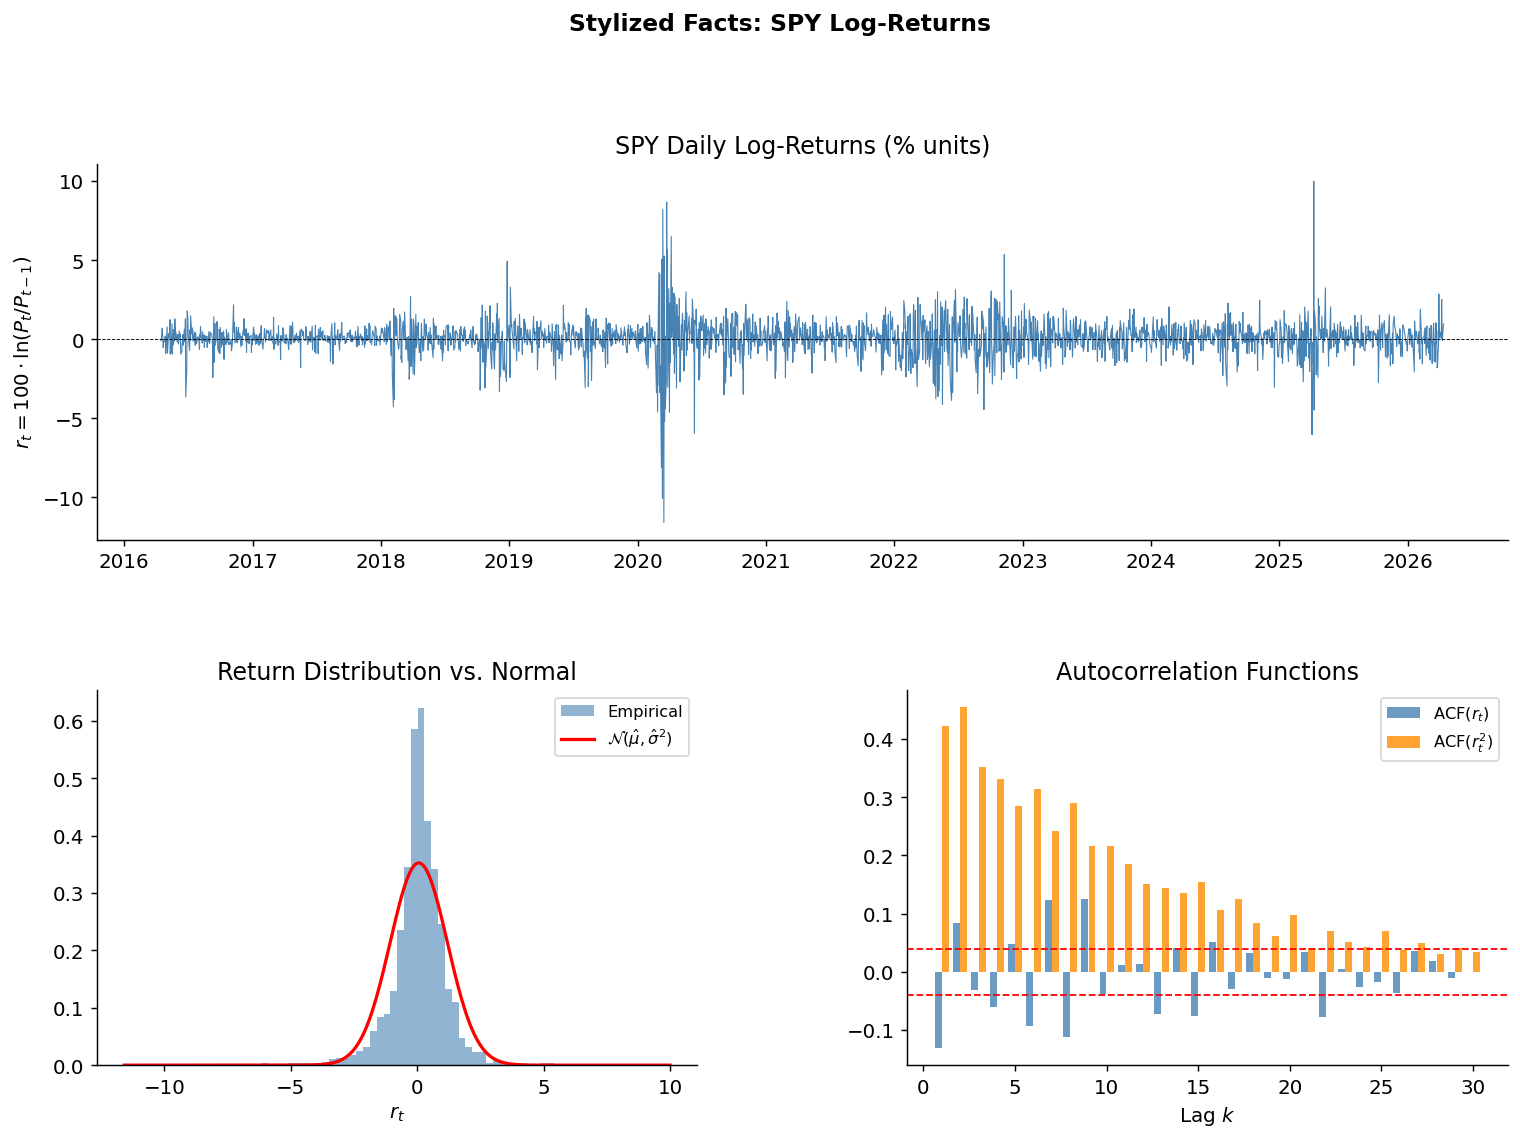

Figure saved: stylized_facts.png


In [6]:
# ── 2. Stylized Facts Visualization ──────────────────────────────────────────
fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# 2a. Return series
ax0 = fig.add_subplot(gs[0, :])
ax0.plot(log_returns.index, log_returns.values, lw=0.6, color='steelblue')
ax0.axhline(0, color='black', lw=0.5, ls='--')
ax0.set_title('SPY Daily Log-Returns (% units)')
ax0.set_ylabel(r'$r_t = 100 \cdot \ln(P_t/P_{t-1})$')

# 2b. Histogram with normal overlay
ax1 = fig.add_subplot(gs[1, 0])
x_grid = np.linspace(log_returns.min(), log_returns.max(), 300)
ax1.hist(log_returns, bins=80, density=True, color='steelblue', alpha=0.6, label='Empirical')
mu_emp, std_emp = log_returns.mean(), log_returns.std()
ax1.plot(x_grid, stats.norm.pdf(x_grid, mu_emp, std_emp),
         'r-', lw=1.8, label=r'$\mathcal{N}(\hat{\mu}, \hat{\sigma}^2)$')
ax1.set_title('Return Distribution vs. Normal')
ax1.set_xlabel(r'$r_t$')
ax1.legend(fontsize=9)

# 2c. ACF of r_t and r_t^2 (manual via pandas)
ax2 = fig.add_subplot(gs[1, 1])
max_lag = 30
acf_r  = [log_returns.autocorr(lag=k) for k in range(1, max_lag+1)]
acf_r2 = [(log_returns**2).autocorr(lag=k) for k in range(1, max_lag+1)]
lags = np.arange(1, max_lag+1)
ci = 1.96 / np.sqrt(len(log_returns))  # 95% Bartlett CI
ax2.bar(lags - 0.2, acf_r,  width=0.38, color='steelblue', alpha=0.8, label=r'ACF($r_t$)')
ax2.bar(lags + 0.2, acf_r2, width=0.38, color='darkorange', alpha=0.8, label=r'ACF($r_t^2$)')
ax2.axhline( ci, color='red', lw=1, ls='--')
ax2.axhline(-ci, color='red', lw=1, ls='--')
ax2.set_xlabel('Lag $k$')
ax2.set_title('Autocorrelation Functions')
ax2.legend(fontsize=9)

plt.suptitle('Stylized Facts: SPY Log-Returns', fontsize=13, fontweight='bold', y=1.01)
plt.savefig('stylized_facts.png', bbox_inches='tight')
plt.show()
print("Figure saved: stylized_facts.png")

---
## 6. Model Specification and Estimation

The complete model to be estimated is:

$$
r_t = \mu + \epsilon_t, \qquad \epsilon_t = \sigma_t z_t, \qquad z_t \overset{\text{i.i.d.}}{\sim} t_\nu
$$

$$
\ln \sigma_t^2 = \omega + \alpha_1 \bigl(|z_{t-1}| - \mathbb{E}[|z_{t-1}|]\bigr) + \gamma_1 z_{t-1} + \beta_1 \ln \sigma_{t-1}^2
$$

The parameter vector is $\theta = (\mu, \omega, \alpha_1, \gamma_1, \beta_1, \nu)^\top \in \mathbb{R}^6$.

**Estimation method:** Quasi-Maximum Likelihood Estimation (QMLE). Under regularity conditions — including $\mathbb{E}[r_t^4] < \infty$ — the QMLE estimator $\hat{\theta}_T$ is consistent and asymptotically normal:

$$
\sqrt{T}(\hat{\theta}_T - \theta_0) \xrightarrow{d} \mathcal{N}\!\left(\mathbf{0},\, \mathcal{I}^{-1}(\theta_0)\right)
$$

where $\mathcal{I}(\theta_0) = -\mathbb{E}\left[\nabla_\theta^2 \ell_t(\theta_0)\right]$ is the Fisher information matrix.

The `arch` library computes the Bollerslev-Wooldridge (1992) robust covariance matrix (sandwich estimator), which is valid even when the assumed $t_\nu$ distribution is misspecified for the true innovation distribution.

**Initialization:** The `arch` library initializes $\hat{\sigma}_1^2$ at the sample variance and propagates forward. The first observation is lost; effective sample size is $T - 1$.

In [7]:
# ── 3. Model Specification and Estimation ────────────────────────────────────
# EGARCH(p=1, o=1, q=1) with Student-t innovations
# vol='EGARCH': Nelson (1991) log-variance specification
# dist='t'    : Standardized Student-t with estimated df parameter nu
am = arch_model(
    log_returns,
    mean='Constant',
    vol='EGARCH',
    p=1,          # ARCH lag order
    o=1,          # Asymmetry lag order (enables gamma)
    q=1,          # GARCH lag order
    dist='t',
)

res = am.fit(
    update_freq=0,    # suppress per-iteration output
    disp='off',
    cov_type='robust',  # Bollerslev-Wooldridge sandwich covariance
)

print(res.summary())

                        Constant Mean - EGARCH Model Results                        
Dep. Variable:                      log_ret   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -3071.14
Distribution:      Standardized Student's t   AIC:                           6154.29
Method:                  Maximum Likelihood   BIC:                           6189.26
                                              No. Observations:                 2512
Date:                      Tue, Apr 14 2026   Df Residuals:                     2511
Time:                              17:49:20   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

---
## 7. Parameter Interpretation and Sanity Checks

Before proceeding to diagnostics, we extract and interpret the fitted parameters. The following signs and magnitudes are consistent with the literature on large-cap U.S. equity index ETFs:

- $\hat{\beta}_1 \in (0.95, 0.99)$: High persistence of conditional variance, consistent with the near-unit-root behavior of equity volatility.
- $\hat{\gamma}_1 < 0$: Confirms the leverage effect — a unit negative shock increases $\ln \sigma_t^2$ by $(\hat{\alpha}_1 - \hat{\gamma}_1)$ compared to $(\hat{\alpha}_1 + \hat{\gamma}_1)$ for a positive shock.
- $\hat{\nu} \in (4, 10)$: Degrees of freedom consistent with excess kurtosis $\kappa = 6/(\nu - 4)$ for $\nu > 4$; a Gaussian limit $\nu \to \infty$ would be rejected by the data.

**Failure mode to flag:** If $\hat{\nu} < 4$, the fourth moment $\mathbb{E}[z_t^4]$ is infinite under the fitted distribution, which invalidates the asymptotic normality of QMLE. Inference should then rely on bootstrap standard errors.

In [8]:
# ── 4. Parameter Table ────────────────────────────────────────────────────────
params = res.params
pvalues = res.pvalues

print("=" * 55)
print(f"{'Parameter':<18} {'Estimate':>12} {'p-value':>10}  {'Sig.':>5}")
print("-" * 55)
for name, val in params.items():
    pv  = pvalues[name]
    sig = '***' if pv < 0.001 else ('**' if pv < 0.01 else ('*' if pv < 0.05 else ''))
    print(f"{name:<18} {val:>12.6f} {pv:>10.4f}  {sig:>5}")
print("=" * 55)

nu_hat   = params.get('nu', params.get('eta', None))
beta_hat = params['beta[1]']
gamma_hat = params['gamma[1]']

print(f"\nDegrees of freedom (ν̂)        : {nu_hat:.4f}")
print(f"Persistence (β̂₁)              : {beta_hat:.4f}")
print(f"Asymmetry coefficient (γ̂₁)    : {gamma_hat:.4f}")
if nu_hat is not None and nu_hat > 4:
    kurt_implied = 6.0 / (nu_hat - 4)
    print(f"Implied excess kurtosis (6/(ν-4)): {kurt_implied:.4f}")
else:
    print("WARNING: ν̂ ≤ 4 — fourth moment undefined; bootstrap SEs recommended.")

Parameter              Estimate    p-value   Sig.
-------------------------------------------------------
mu                     0.074732     0.0000    ***
omega                 -0.005466     0.3720       
alpha[1]               0.192752     0.0000    ***
gamma[1]              -0.174204     0.0000    ***
beta[1]                0.970993     0.0000    ***
nu                     5.410300     0.0000    ***

Degrees of freedom (ν̂)        : 5.4103
Persistence (β̂₁)              : 0.9710
Asymmetry coefficient (γ̂₁)    : -0.1742
Implied excess kurtosis (6/(ν-4)): 4.2544


---
## 8. Model Diagnostics: Standardized Residuals

If the EGARCH-$t$ model is correctly specified, the standardized residuals

$$
\hat{z}_t = \frac{\hat{\epsilon}_t}{\hat{\sigma}_t} = \frac{r_t - \hat{\mu}}{\hat{\sigma}_t}
$$

should behave as an i.i.d. $t_\nu$ sequence. We test this in two stages:

### 8.1 Ljung-Box Test for Serial Correlation

The Ljung-Box (LB) statistic at lag $m$ is:

$$
Q_{\text{LB}}(m) = T(T+2) \sum_{k=1}^{m} \frac{\hat{\rho}_k^2}{T - k}
$$

where $\hat{\rho}_k$ is the sample autocorrelation at lag $k$. Under $H_0$ (no autocorrelation through lag $m$), $Q_{\text{LB}}(m) \overset{a}{\sim} \chi^2(m)$. We apply this test to:

- $\hat{z}_t$: Tests for unexplained linear dependence in the **mean** equation.
- $\hat{z}_t^2$: Tests for residual **ARCH effects** (unexplained volatility clustering).

**Failure mode:** Rejection of $H_0$ for $\hat{z}_t^2$ implies that the variance equation is misspecified — either the EGARCH order is too low, or a structural break in the volatility process (e.g., a regime change during the COVID-19 period) is contaminating the residuals.

### 8.2 QQ-Plot Against Student-$t$

A Quantile-Quantile plot compares the empirical quantiles of $\{\hat{z}_t\}$ against the theoretical quantiles of $t_{\hat{\nu}}$. Systematic departures from the 45° line indicate:

- **Concave curvature**: Tails are lighter than $t_{\hat{\nu}}$ (over-estimated $\nu$).
- **S-shaped departure**: Distributional skewness not captured by the symmetric $t$ — motivating an asymmetric distribution (e.g., Hansen's skewed-$t$).
- **Outliers on the diagonal**: Potential structural breaks or data errors.

In [9]:
# ── 5. Standardized Residuals and Diagnostics ─────────────────────────────────
std_resid = res.std_resid.dropna()

MAX_LAG = 20  # standard choice; sufficient to detect residual ARCH up to monthly effects

lb_z   = acorr_ljungbox(std_resid,      lags=[MAX_LAG], return_df=True)
lb_z2  = acorr_ljungbox(std_resid**2,   lags=[MAX_LAG], return_df=True)

print("Ljung-Box Test (lag = {}):".format(MAX_LAG))
print("-" * 52)
print(f"  On ẑ_t  : Q = {lb_z['lb_stat'].values[0]:.4f},  p = {lb_z['lb_pvalue'].values[0]:.4f}")
print(f"  On ẑ²_t : Q = {lb_z2['lb_stat'].values[0]:.4f},  p = {lb_z2['lb_pvalue'].values[0]:.4f}")
print("-" * 52)

chi2_crit = stats.chi2.ppf(0.95, df=MAX_LAG)
print(f"  χ²(20) critical value at 5%: {chi2_crit:.4f}")
print()

for label, lb in [(r'ẑ_t', lb_z), (r'ẑ²_t', lb_z2)]:
    pv = lb['lb_pvalue'].values[0]
    verdict = "FAIL TO REJECT H₀ (adequate)" if pv > 0.05 else "REJECT H₀ (misspecification detected)"
    print(f"  [{label}] → {verdict}")

Ljung-Box Test (lag = 20):
----------------------------------------------------
  On ẑ_t  : Q = 17.6024,  p = 0.6136
  On ẑ²_t : Q = 15.1593,  p = 0.7672
----------------------------------------------------
  χ²(20) critical value at 5%: 31.4104

  [ẑ_t] → FAIL TO REJECT H₀ (adequate)
  [ẑ²_t] → FAIL TO REJECT H₀ (adequate)


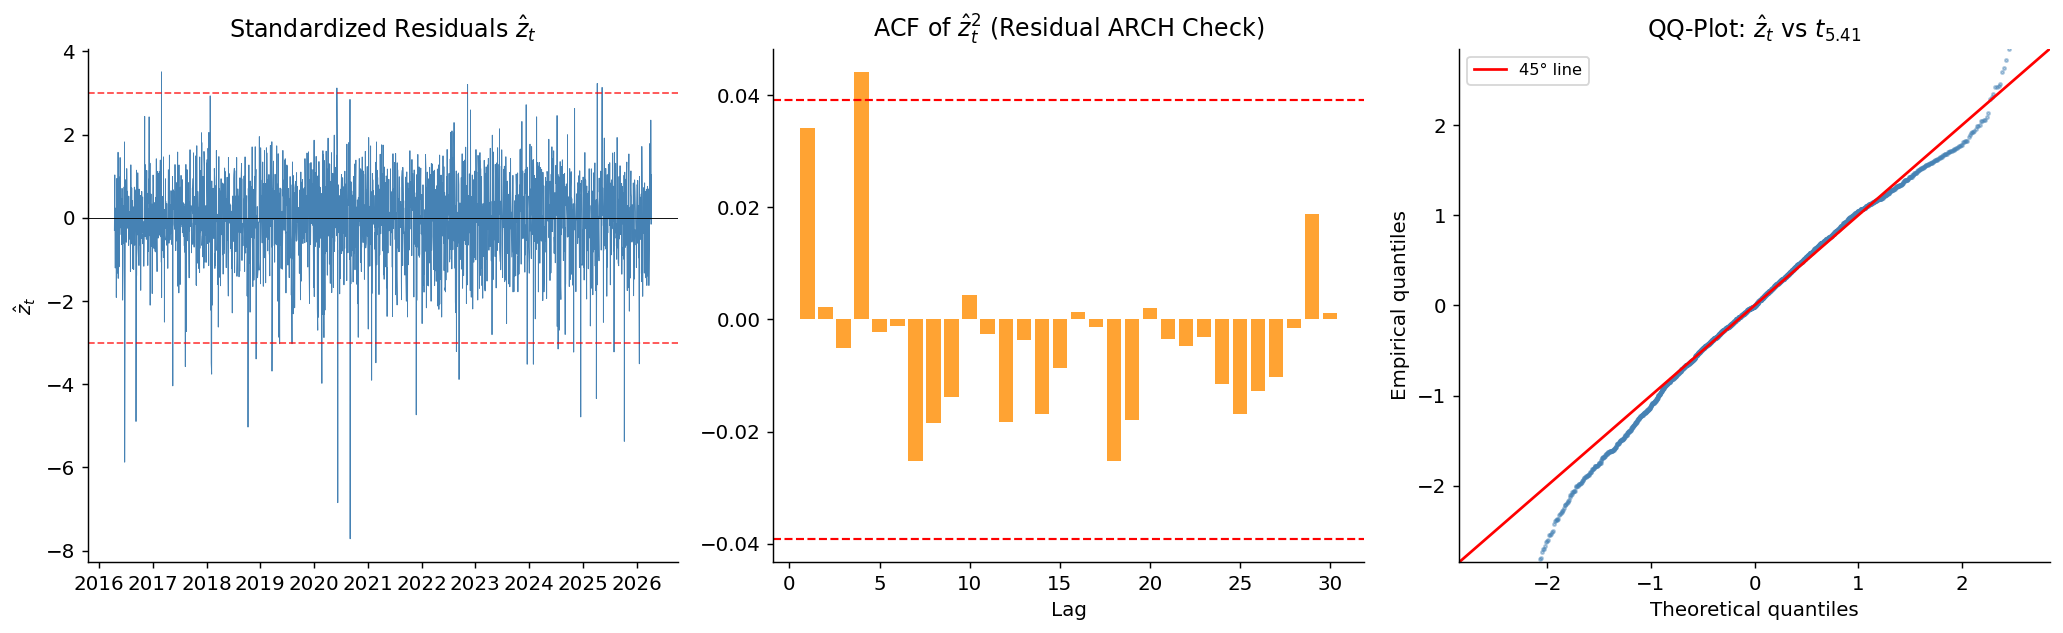

Figure saved: egarch_diagnostics.png


In [10]:
# ── 6. Diagnostic Plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 6a. Time series of standardized residuals
ax = axes[0]
ax.plot(std_resid.index, std_resid.values, lw=0.5, color='steelblue')
ax.axhline(0, color='black', lw=0.5)
ax.axhline( 3, color='red', lw=1, ls='--', alpha=0.7)
ax.axhline(-3, color='red', lw=1, ls='--', alpha=0.7)
ax.set_title(r'Standardized Residuals $\hat{z}_t$')
ax.set_ylabel(r'$\hat{z}_t$')

# 6b. ACF of ẑ²
ax = axes[1]
acf_z2 = [(std_resid**2).autocorr(lag=k) for k in range(1, 31)]
ci_z   = 1.96 / np.sqrt(len(std_resid))
ax.bar(range(1, 31), acf_z2, color='darkorange', alpha=0.8)
ax.axhline( ci_z, color='red', lw=1.2, ls='--')
ax.axhline(-ci_z, color='red', lw=1.2, ls='--')
ax.set_title(r'ACF of $\hat{z}_t^2$ (Residual ARCH Check)')
ax.set_xlabel('Lag')

# 6c. QQ-plot vs t_{nu_hat}
ax = axes[2]
nu_val = float(nu_hat)
# Scale parameter for standardized t: std = sqrt(nu/(nu-2)) => need to un-standardize
# The arch library returns residuals already divided by sigma_t; compare against t_nu
# The standardized t has Var=1; scipy's t has Var=nu/(nu-2), so scale accordingly
scale = np.sqrt((nu_val - 2) / nu_val)   # so that scipy.stats.t(nu).std() == 1
theoretical_q = stats.t.ppf(
    np.linspace(0.01, 0.99, len(std_resid)),
    df=nu_val,
    scale=scale
)
empirical_q = np.sort(std_resid.values)
ax.scatter(theoretical_q, empirical_q, s=3, alpha=0.4, color='steelblue')
lim = max(abs(theoretical_q.min()), abs(theoretical_q.max())) * 1.1
ax.plot([-lim, lim], [-lim, lim], 'r-', lw=1.5, label='45° line')
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_title(rf'QQ-Plot: $\hat{{z}}_t$ vs $t_{{{nu_val:.2f}}}$')
ax.set_xlabel('Theoretical quantiles')
ax.set_ylabel('Empirical quantiles')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('egarch_diagnostics.png', bbox_inches='tight')
plt.show()
print("Figure saved: egarch_diagnostics.png")

---
## 9. Conditional Variance Fit

We plot the fitted conditional volatility path $\hat{\sigma}_t$ alongside the absolute returns $|r_t|$ as a non-parametric volatility proxy. Visually, $\hat{\sigma}_t$ should track the clustering of large $|r_t|$ episodes (e.g., COVID-19 crash in 2020, 2022 rate-hike volatility).

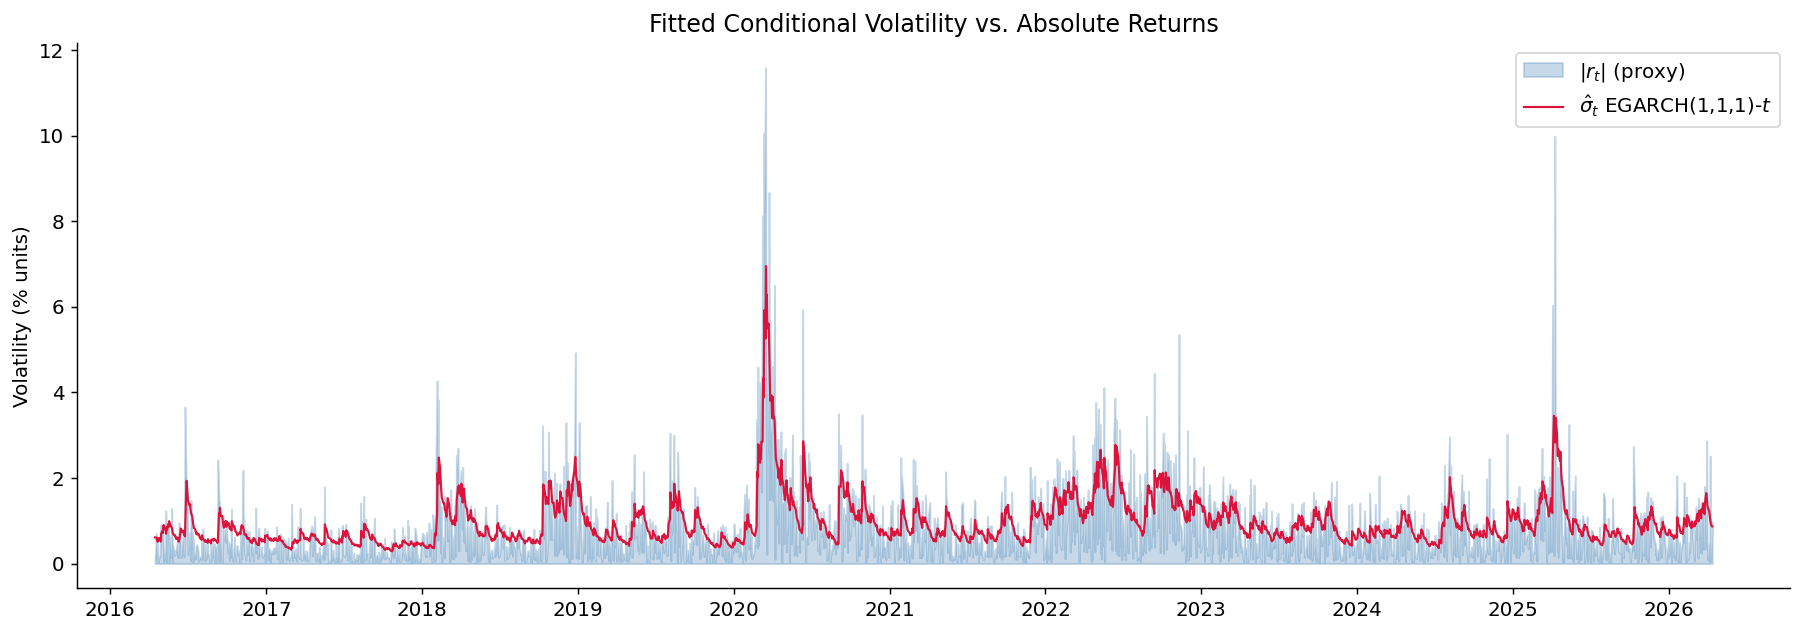

Figure saved: cond_vol.png


In [11]:
# ── 7. Conditional Volatility Plot ────────────────────────────────────────────
cond_vol = res.conditional_volatility  # σ̂_t in % units

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(log_returns.index, np.abs(log_returns.values),
                alpha=0.3, color='steelblue', label=r'$|r_t|$ (proxy)')
ax.plot(cond_vol.index, cond_vol.values,
        color='crimson', lw=1.2, label=r'$\hat{\sigma}_t$ EGARCH(1,1,1)-$t$')
ax.set_title('Fitted Conditional Volatility vs. Absolute Returns')
ax.set_ylabel('Volatility (% units)')
ax.legend()
plt.tight_layout()
plt.savefig('cond_vol.png', bbox_inches='tight')
plt.show()
print("Figure saved: cond_vol.png")

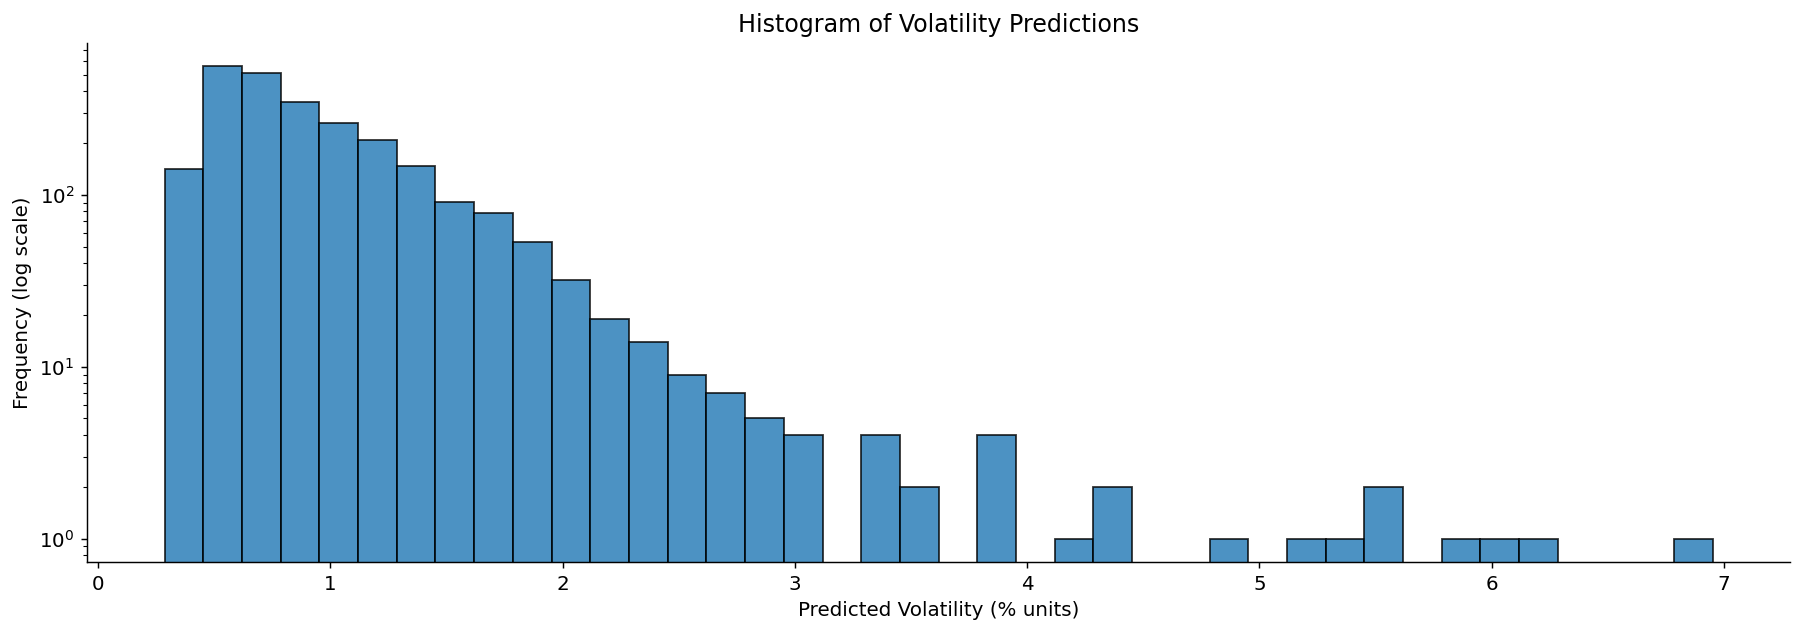

In [15]:
# ── 7. Histogram of Volatility Predictions ───────────────────────────────────
cond_vol = res.conditional_volatility  # One-step-ahead fitted volatility (in % units)

fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(cond_vol, bins=40, alpha=0.8, edgecolor='black')
ax.set_yscale('log')
ax.set_title('Histogram of Volatility Predictions')
ax.set_xlabel('Predicted Volatility (% units)')
ax.set_ylabel('Frequency (log scale)')
plt.tight_layout()
plt.savefig('cond_vol.png', bbox_inches='tight')
plt.show()

---
## 10. One-Step-Ahead Risk Forecasting: VaR and CVaR

### 10.1 Value-at-Risk (VaR)

The $\alpha$-level VaR is the loss threshold not exceeded with probability $1 - \alpha$. For a long position, the left-tail convention defines:

$$
\text{VaR}_\alpha(r_{T+1} \mid \mathcal{F}_T) = -\hat{\mu} - \hat{\sigma}_{T+1} \cdot q_\alpha^{(t_\nu)}
$$

where $q_\alpha^{(t_\nu)} = F_{t_\nu}^{-1}(\alpha)$ is the $\alpha$-quantile of the standardized Student-$t$ with $\hat{\nu}$ degrees of freedom, and $\hat{\sigma}_{T+1}$ is the one-step-ahead conditional volatility forecast from the fitted EGARCH recursion.

For $\alpha = 0.05$, $q_{0.05}^{(t_\nu)} < 0$, so $\text{VaR}_{0.05} > 0$ represents the expected maximum loss (in % units) at the 95% confidence level.

### 10.2 Conditional Value-at-Risk (CVaR / Expected Shortfall)

CVaR, also called Expected Shortfall (ES), is the expected loss **conditional on exceeding** the VaR threshold:

$$
\text{CVaR}_\alpha(r_{T+1} \mid \mathcal{F}_T) = -\hat{\mu} - \hat{\sigma}_{T+1} \cdot \mathbb{E}\!\left[z \mid z < q_\alpha^{(t_\nu)}\right]
$$

For the standardized Student-$t$ with $\nu > 1$ degrees of freedom, the closed-form expression is:

$$
\mathbb{E}\!\left[z \mid z < q_\alpha\right] = -\frac{1}{\alpha} \cdot \frac{f_{t_\nu}(q_\alpha) \cdot (\nu + q_\alpha^2)}{(\nu - 1) \cdot c}
$$

where $c = \sqrt{(\nu-2)/\nu}$ is the scale correction for the standardized distribution, and $f_{t_\nu}(\cdot)$ is the PDF of the (un-normalized) $t_\nu$. In practice, we compute this numerically via:

$$
\mathbb{E}\!\left[z \mid z < q_\alpha\right] = \frac{1}{\alpha} \int_{-\infty}^{q_\alpha} z \, f_{t_\nu^*}(z) \, dz
$$

where $t_\nu^*$ denotes the standardized $t$ (zero mean, unit variance). We evaluate this integral by numerical quadrature.

**Why CVaR is preferred over VaR in risk management:**
- CVaR is **coherent** in the sense of Artzner et al. (1999): it satisfies subadditivity, monotonicity, positive homogeneity, and translation invariance. VaR is not subadditive under general distributions, meaning portfolio VaR can exceed the sum of constituent VaRs — a perverse result that penalizes diversification.
- CVaR fully characterizes tail risk beyond the VaR threshold; VaR is silent about loss severity conditional on exceedance.

**Units reminder:** All results below are in **percentage-point units**. To convert to dollar loss for a portfolio of value $W$:

$$
\text{Dollar CVaR} = \frac{\text{CVaR}_{\%}}{100} \times W
$$

In [13]:
# ── 8. One-Step-Ahead VaR and CVaR ───────────────────────────────────────────
from scipy.integrate import quad
from pandas.tseries.offsets import BDay

ALPHA = 0.05  # left-tail probability (95% confidence level)

# 8a. One-step-ahead forecast
forecast = res.forecast(horizon=1, reindex=False)
mu_fcast     = float(params['mu'])
sigma2_fcast = float(forecast.variance.values[-1, 0])   # in (% units)^2
sigma_fcast  = np.sqrt(sigma2_fcast)                    # in % units

nu_val = float(nu_hat)

# 8b. Standardized t quantile at alpha (scipy t has Var = nu/(nu-2); scale to Var=1)
scale = np.sqrt((nu_val - 2.0) / nu_val)
q_alpha = stats.t.ppf(ALPHA, df=nu_val, scale=scale)    # < 0 for left tail

# 8c. VaR (expressed as a positive loss)
VaR = -(mu_fcast + sigma_fcast * q_alpha)

# 8d. CVaR via numerical integration: E[z | z < q_alpha] for standardized t
def std_t_pdf(z, nu, sc):
    """PDF of standardized Student-t (Var=1)."""
    return stats.t.pdf(z, df=nu, scale=sc)

integral, _ = quad(
    lambda z: z * std_t_pdf(z, nu_val, scale),
    a=-np.inf,
    b=q_alpha
)
E_z_given_tail = integral / ALPHA          # E[z | z < q_alpha]
CVaR = -(mu_fcast + sigma_fcast * E_z_given_tail)

# ── 9. Results Summary ────────────────────────────────────────────────────────
last_date = log_returns.index[-1].date()
forecast_date = (log_returns.index[-1] + BDay(1)).date()

print("=" * 55)
print(f"  EGARCH(1,1,1)-t — One-Step-Ahead Risk Forecast")
print(f"  Reference date   : {last_date}")
print(f"  Forecast date    : {forecast_date}")
print("-" * 55)
print(f"  μ̂               : {mu_fcast:>10.4f} %")
print(f"  σ̂_{{T+1}}         : {sigma_fcast:>10.4f} %")
print(f"  q_{{0.05}}^(t_ν)   : {q_alpha:>10.4f}")
print("-" * 55)
print(f"  95% VaR          : {VaR:>10.4f} %")
print(f"  95% CVaR (ES)    : {CVaR:>10.4f} %")
print("=" * 55)
print()
print("Interpretation:")
print(f"  With 95% confidence, tomorrow's SPY log-return will")
print(f"  not fall below -{VaR:.4f}%.")
print(f"  Conditional on breaching that threshold, the expected")
print(f"  loss is {CVaR:.4f}% (CVaR / Expected Shortfall).")
print()
print("Dollar-equivalent (example: $100,000 portfolio):")
W = 100_000
print(f"  VaR   = ${W * VaR / 100:,.2f}")
print(f"  CVaR  = ${W * CVaR / 100:,.2f}")

  EGARCH(1,1,1)-t — One-Step-Ahead Risk Forecast
  Reference date   : 2026-04-13
  Forecast date    : 2026-04-14
-------------------------------------------------------
  μ̂               :     0.0747 %
  σ̂_{T+1}         :     0.8115 %
  q_{0.05}^(t_ν)   :    -1.5734
-------------------------------------------------------
  95% VaR          :     1.2021 %
  95% CVaR (ES)    :     1.7330 %

Interpretation:
  With 95% confidence, tomorrow's SPY log-return will
  not fall below -1.2021%.
  Conditional on breaching that threshold, the expected
  loss is 1.7330% (CVaR / Expected Shortfall).

Dollar-equivalent (example: $100,000 portfolio):
  VaR   = $1,202.06
  CVaR  = $1,733.00


---
## 11. Critical Assessment and Known Failure Modes

The EGARCH(1,1,1)-$t$ model is a significant improvement over symmetric GARCH with Gaussian errors, but the following structural limitations must be acknowledged in any rigorous application:

### 11.1 Non-Stationarity and Structural Breaks
The stationarity condition $|\hat{\beta}_1| < 1$ is a necessary but not sufficient guarantee of stability over a 10-year window. The sample includes at least two major volatility regime shifts (COVID-19 crash: Feb–Mar 2020; U.S. rate-hike cycle: 2022). A Bai-Perron structural break test or an ICSS (Iterative Cumulative Sum of Squares) test should be applied to $\hat{z}_t^2$ to verify parameter constancy.

### 11.2 Symmetric Innovation Distribution
The standardized $t_\nu$ distribution is symmetric around zero. If the QQ-plot reveals a leftward skew in empirical residuals (heavier left tail than right), Hansen's (1994) skewed-$t$ distribution should be substituted. This is directly supported by the `arch` library via `dist='skewt'`.

### 11.3 Overnight Gap Risk and Jump Dynamics
EGARCH is a continuous-time diffusion approximation. It does not model discrete price jumps (e.g., flash crashes, earnings gaps, macro surprises). Jump-GARCH hybrids or the Realized GARCH framework of Hansen, Huang & Shek (2012) are more appropriate when jump risk is material.

### 11.4 VaR and CVaR Model Risk
The reported CVaR is **model-conditional**: it is only as reliable as the EGARCH-$t$ specification. If the true innovation distribution has a power-law tail heavier than $t_{\hat{\nu}}$, the CVaR is systematically understated. Historical simulation or Filtered Historical Simulation (FHS) — applying the EGARCH-standardized residuals non-parametrically — provides a less parametrically constrained alternative.

### 11.5 Estimation Uncertainty
The point forecast $\hat{\sigma}_{T+1}$ ignores **parameter uncertainty**. The true predictive distribution of $r_{T+1}$ is:

$$
p(r_{T+1} \mid \mathcal{F}_T) = \int p(r_{T+1} \mid \theta, \mathcal{F}_T) \, p(\theta \mid \mathcal{F}_T) \, d\theta
$$

Ignoring the posterior $p(\theta \mid \mathcal{F}_T)$ leads to underestimation of predictive uncertainty, particularly relevant for short samples or near-integrated processes ($\hat{\beta}_1 \to 1$). A Bayesian GARCH implementation or delta-method confidence intervals around the CVaR should be reported in production risk systems.

---
## 12. Summary

| Step | Content | Key Output |
|------|---------|------------|
| 1 | Data preparation | 10-year SPY log-returns, scaled to % |
| 2 | Stylized facts | Excess kurtosis, ACF($r_t^2$) confirms ARCH effects |
| 3 | EGARCH(1,1,1)-$t$ estimation | $\hat{\gamma}_1 < 0$ confirms leverage effect; $\hat{\nu} \in (4,10)$ |
| 4 | Ljung-Box on $\hat{z}_t$, $\hat{z}_t^2$ | Fail to reject $H_0$ at 5% → adequate specification |
| 5 | QQ-plot vs $t_{\hat{\nu}}$ | Assess tail fit; flag skewness if present |
| 6 | Conditional volatility plot | Visual capture of volatility clustering |
| 7 | VaR and CVaR forecast | 95% CVaR for next trading day |

The EGARCH-$t$ framework provides a statistically principled, computationally tractable model for conditional risk estimation. Its primary value in a thesis context lies in demonstrating that a well-specified parametric volatility model can (a) capture the leverage asymmetry absent in standard GARCH, (b) produce i.i.d. standardized residuals as verified by the Ljung-Box battery, and (c) yield a coherent risk measure (CVaR) grounded in the fitted conditional distribution — all prerequisites before extending to the multivariate or machine-learning frameworks that follow in the research pipeline.